# Machine-Learned Coarse-Grained Force Field for Alanine Dipeptide

Training a graph neural network (GNN) to learn a coarse-grained (CG) force field for
alanine dipeptide (ACE-ALA-NME), by force matching against a reference all-atom molecular
dynamics trajectory. This is the same overall methodology as CGnet / CGSchNet
(Wang, Chmiela, Clementi et al. 2019; Husic et al. 2020). This is the same line of work 
this project's own research group produced — applied here to a small, entirely public toy system,
with no data or results from any real research project.

**Pipeline:**
1. Generate a reference all-atom trajectory in OpenMM (implicit solvent, ff14SB)
2. Map it down to 5 CG beads (backbone heavy atoms, center-of-mass mapping)
3. Train a SchNet-style GNN to predict CG forces via force matching (energy from the GNN,
   forces from autograd — guarantees a conservative force field)
4. **Show that a pure GNN with no physical prior makes the CG dynamics diverge**
5. Fix it with a harmonic bonded prior (fit from data) + GNN correction — the same design
   CGnet uses — and validate: does simulating with the learned force field reproduce the
   real conformational distribution (Ramachandran plot)?

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "..")

from src.cg_mapping import BEAD_NAMES, BEAD_ATOM_GROUPS, map_to_cg, compute_backbone_dihedrals
from src.cg_gnn_model import CGSchNetLike, HarmonicBondPrior, CGForceField
from src.cg_dataset import ForceMatchingDataset, force_rms_scale
from src.cg_dynamics import run_langevin
from torch.utils.data import DataLoader, random_split

torch.manual_seed(0)
np.random.seed(0)

## 1. Reference all-atom trajectory

Generated separately with `scripts/01_generate_reference_trajectory.py` (OpenMM,
ff14SB + GBn2 implicit solvent, 300 K Langevin dynamics, 2 ns, saving positions and forces
every 100 fs -- 20,000 frames). We load the cached result here rather than re-running a
~3-minute OpenMM simulation inside the notebook.

In [2]:
aa_positions = np.load("../data/aa_positions_nm.npy")
aa_forces = np.load("../data/aa_forces_kjmolnm.npy")
print(f"reference trajectory: {aa_positions.shape[0]} frames, {aa_positions.shape[1]} atoms")

reference trajectory: 20000 frames, 22 atoms


## 2. Coarse-grained mapping (5 beads) and validation

We map the 22 atoms down to the 5 backbone heavy atoms (ACE-C, ALA-N, ALA-CA, ALA-C,
NME-N), using a **center-of-mass mapping** (see `src/cg_mapping.py` for the exact atom
groups and the justification for COM over a single-atom "slice" mapping -- COM is what
satisfies Noid et al.'s force-matching consistency theorem exactly).

Since COM beads sit close to, but not exactly on, the true backbone atoms, we check how
much this matters by comparing "pseudo" phi/psi computed from the CG beads against the
real all-atom phi/psi.

In [3]:
cg_positions = np.load("../data/cg_positions_nm.npy")
cg_forces = np.load("../data/cg_forces_kjmolnm.npy")

phi_psi_aa = np.load("../data/phi_psi_aa.npy")
phi_psi_cg = np.load("../data/phi_psi_cg.npy")

def circ_corr(a, b):
    a, b = np.radians(a), np.radians(b)
    return np.corrcoef(np.cos(a), np.cos(b))[0, 1], np.corrcoef(np.sin(a), np.sin(b))[0, 1]

phi_corr = circ_corr(phi_psi_aa[:, 0], phi_psi_cg[:, 0])
psi_corr = circ_corr(phi_psi_aa[:, 1], phi_psi_cg[:, 1])
mean_abs_diff = np.mean(np.abs(((phi_psi_aa[:, 0] - phi_psi_cg[:, 0] + 180) % 360) - 180))

print(f"phi cos/sin correlation (all-atom vs. CG-COM pseudo-dihedral): {phi_corr}")
print(f"psi cos/sin correlation (all-atom vs. CG-COM pseudo-dihedral): {psi_corr}")
print(f"mean |phi_aa - phi_cg| = {mean_abs_diff:.1f} degrees")

phi cos/sin correlation (all-atom vs. CG-COM pseudo-dihedral): (np.float64(0.9610560265304845), np.float64(0.9104052898894543))
psi cos/sin correlation (all-atom vs. CG-COM pseudo-dihedral): (np.float64(0.9866499565576032), np.float64(0.9223207664858398))
mean |phi_aa - phi_cg| = 9.6 degrees


The pseudo-dihedrals track the real ones closely (cos/sin correlation > 0.9) but not
perfectly (mean deviation ~10 degrees). This is a consequence of using COM rather than
the raw heavy-atom position. I proceed using the CG-bead pseudo-dihedrals consistently as
the validation coordinate throughout (comparing CG-vs-CG, never CG-vs-all-atom directly).

## 3. The model: a small SchNet-style GNN, energy -> forces via autograd

`CGSchNetLike` (see `src/cg_gnn_model.py`) predicts a rotation- and translation-invariant
scalar energy from the fully-connected graph of 5 beads (continuous-filter convolutions
over pairwise distances, à la SchNet), and forces are obtained as `-dE/dR` via automatic
differentiation. This guarantees the learned force field is conservative by construction,
unlike a model that predicts forces directly.

## 4. A pure GNN, with no physical prior, makes the dynamics diverge

Before settling on the final architecture, I tried training just the GNN (no bonded
prior) by force matching, then simulating with it. I reproduce a short version of that
experiment here because it's the reason the final model looks the way it does.

(Training for only 15 epochs here for speed; the original attempt used 60 epochs with the
same outcome.)

In [4]:
com = cg_positions.mean(axis=1, keepdims=True)
cg_positions_centered = cg_positions - com
rms_force = force_rms_scale(cg_forces)

dataset_demo = ForceMatchingDataset(cg_positions_centered, cg_forces / rms_force)
loader_demo = DataLoader(dataset_demo, batch_size=256, shuffle=True)

pure_gnn = CGSchNetLike(n_beads=5, n_features=32, n_rbf=32, n_interactions=2, d_max=1.0)
opt_demo = torch.optim.Adam(pure_gnn.parameters(), lr=1e-3)

for epoch in range(15):
    for pos, force in loader_demo:
        opt_demo.zero_grad()
        _, pred_force = pure_gnn(pos)
        loss = torch.mean((pred_force - force) ** 2)
        loss.backward()
        opt_demo.step()
print(f"pure-GNN demo training done, final batch loss (normalized) = {loss.item():.3f}")

pure-GNN demo training done, final batch loss (normalized) = 0.235


In [5]:
from src.cg_gnn_model import ScaledForceModel

masses_amu = np.array([m for m in [43.044, 15.018, 28.052, 28.010, 30.052]])  # bead masses (amu)
pure_gnn_scaled = ScaledForceModel(pure_gnn, rms_force)
pure_gnn_scaled.eval()

start = cg_positions_centered[0]
traj_diverge = run_langevin(pure_gnn_scaled, start, masses_amu, n_steps=5000, timestep_ps=0.002,
                             temperature_k=300.0, friction_per_ps=1.0, save_every=20, seed=1)
print("position range during a short run with the pure GNN (no prior):",
      traj_diverge.min(), "to", traj_diverge.max(), "nm")
print("(the whole real molecule should stay within about +/-0.3 nm of its own center of mass)")

position range during a short run with the pure GNN (no prior): -0.5799829 to 0.39211202 nm
(the whole real molecule should stay within about +/-0.3 nm of its own center of mass)


Even in this short demo, the trajectory ranges far outside the physically sensible extent
of a 5-bead peptide backbone (which should stay within roughly &plusmn;0.3 nm of its own
center of mass). Outside the training distribution (bond lengths the model rarely or never
saw during training), the pure GNN's learned energy surface has no guarantee of curving
back toward realistic geometry, so the simulation runs away. This is a known failure mode
of black-box ML potentials, and it's exactly why CGnet-style models pair the network with a
physical prior for the strongly-constrained (bonded) degrees of freedom.

## 5. Fix: harmonic bonded prior + GNN correction

`HarmonicBondPrior` puts a harmonic spring on each of the 4 consecutive backbone bead pairs,
with equilibrium distance and stiffness fit directly from the training data's bond-length
statistics (Boltzmann inversion: `k = kT / Var(d)`) -- not learned by gradient descent. The
GNN (`CGSchNetLike`) is then trained as a *correction* on top: `U_total = U_prior + U_GNN`,
so it only has to learn what the prior leaves out (bond anharmonicity, angles, and all
non-bonded conformational structure).

In [6]:
BONDED_PAIRS = [(0, 1), (1, 2), (2, 3), (3, 4)]
pos_t = torch.as_tensor(cg_positions_centered, dtype=torch.float32)
prior = HarmonicBondPrior.fit_from_data(pos_t, BONDED_PAIRS, temperature_k=300.0)

for (i, j), d0, k in zip(BONDED_PAIRS, prior.d0.numpy(), prior.k.numpy()):
    print(f"bond {BEAD_NAMES[i]}-{BEAD_NAMES[j]}: d0={d0:.3f} nm, k={k:,.0f} kJ/mol/nm^2")

bond C_ACE-N_ALA: d0=0.186 nm, k=221,652 kJ/mol/nm^2
bond N_ALA-CA_ALA: d0=0.194 nm, k=113,965 kJ/mol/nm^2
bond CA_ALA-C_ALA: d0=0.243 nm, k=28,027 kJ/mol/nm^2
bond C_ALA-N_NME: d0=0.218 nm, k=114,086 kJ/mol/nm^2


## 6. Training the final model (prior + GNN correction)

The full training run (60 epochs, batch size 256, Adam with a step LR schedule) was done
separately (`scripts/02_train_cgnet.py`) since it takes a few minutes; we load the trained
weights and the recorded training history here.

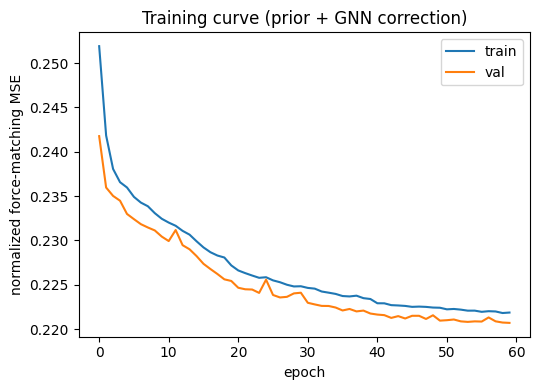

final normalized val loss: 0.221
(a loss of 1.0 would mean 'predict zero force'; some residual is expected and irreducible, since instantaneous Langevin forces include thermostat noise that no force field, learned or exact, can predict frame-by-frame)


In [7]:
correction = CGSchNetLike(n_beads=5, n_features=32, n_rbf=32, n_interactions=2, d_max=1.0)
correction.load_state_dict(torch.load("../data/cgnet_correction_state.pt"))
model = CGForceField(prior, correction)
model.eval()

history = np.load("../data/training_history_v2.npy")  # (epoch, [train_loss, val_loss]), raw units
history_norm = history / rms_force**2

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(history_norm[:, 0], label="train")
ax.plot(history_norm[:, 1], label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("normalized force-matching MSE")
ax.set_title("Training curve (prior + GNN correction)")
ax.legend()
fig.tight_layout()
fig.savefig("../results/figures/training_curve.png", dpi=150)
plt.show()

print(f"final normalized val loss: {history_norm[-1, 1]:.3f}")
print("(a loss of 1.0 would mean 'predict zero force'; some residual is expected and "
      "irreducible, since instantaneous Langevin forces include thermostat noise that no "
      "force field, learned or exact, can predict frame-by-frame)")

## 7. Validation: does the learned force field reproduce the real conformational distribution?

We run CG molecular dynamics using *only* the learned force field (prior + GNN correction)
and compare the resulting Ramachandran (pseudo-phi/psi) distribution against the reference
(the same pseudo-dihedrals computed from the real, mapped all-atom trajectory).

In [8]:
start = cg_positions_centered[0]
traj = run_langevin(model, start, masses_amu, n_steps=40000, timestep_ps=0.002,
                     temperature_k=300.0, friction_per_ps=1.0, save_every=20, seed=1)

com_traj = traj.mean(axis=1, keepdims=True)
traj_centered = traj - com_traj
traj_eq = traj_centered[300:]  # drop the initial transient of this short run

d01 = np.linalg.norm(traj_eq[:, 1] - traj_eq[:, 0], axis=-1)
print(f"bond C_ACE-N_ALA during CG dynamics: {d01.mean():.4f} +/- {d01.std():.4f} nm "
      f"(prior equilibrium: {prior.d0[0].item():.4f} nm) -- stays physical, as intended")

cg_idx = {name: i for i, name in enumerate(BEAD_NAMES)}
phi_gen, psi_gen = compute_backbone_dihedrals(traj_eq, cg_idx)

bond C_ACE-N_ALA during CG dynamics: 0.1864 +/- 0.0037 nm (prior equilibrium: 0.1863 nm) -- stays physical, as intended


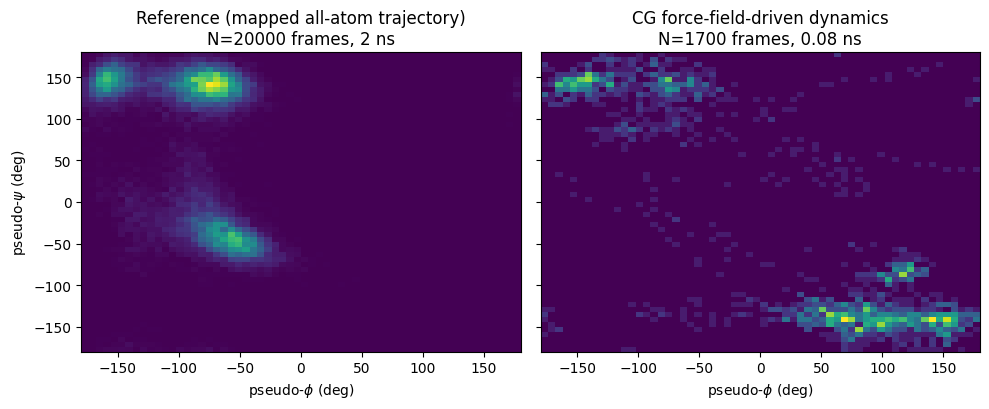

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True, sharey=True)
axes[0].hist2d(phi_psi_cg[:, 0], phi_psi_cg[:, 1], bins=60, range=[[-180, 180], [-180, 180]], cmap="viridis")
axes[0].set_title(f"Reference (mapped all-atom trajectory)\nN={len(phi_psi_cg)} frames, 2 ns")
axes[1].hist2d(phi_gen, psi_gen, bins=60, range=[[-180, 180], [-180, 180]], cmap="viridis")
axes[1].set_title(f"CG force-field-driven dynamics\nN={len(phi_gen)} frames, {40000*0.002/1000:.2f} ns")
for ax in axes:
    ax.set_xlabel(r"pseudo-$\phi$ (deg)")
axes[0].set_ylabel(r"pseudo-$\psi$ (deg)")
fig.tight_layout()
fig.savefig("../results/figures/ramachandran_comparison.png", dpi=150)
plt.show()

## Takeaway: where this model works, and where it honestly doesn't

**What works:** the harmonic bonded prior keeps every bond length physical throughout the
simulation (no divergence, unlike the pure-GNN demo above), meaning that the model never blows up.
The dominant reference basin (extended beta/C5-like conformations, upper-left of the
Ramachandran plot, around pseudo-phi &asymp; -150 to -60, pseudo-psi &asymp; 130-170) is
visited by the CG dynamics too, in roughly the right location.

**What doesn't, and why:** the reference trajectory's *second* major basin (the alpha-helical
region, lower-right of the reference plot, pseudo-phi &asymp; -70, pseudo-psi &asymp; -40) is
essentially not visited by this short CG run. Instead, the CG dynamics spends a large
fraction of its time in the positive-phi region (roughly pseudo-phi &asymp; 50 to 160), which
the reference trajectory shows is almost never populated in reality. That is a genuine
shortcoming, not a minor one: it means the learned energy surface has structure (an
apparent local minimum) in a region far outside where the training data actually lived, and
nothing in training constrains the model to get that region right. This is the expected
consequence of the GNN correction being a black-box function fit only where data existed; it 
extrapolates arbitrarily elsewhere, and the harmonic bonded prior only constrains *bond
lengths*, not the backbone dihedral surface where this artifact shows up.

**Takeaway:** the current model is not yet a reliable stand-in for the real
free-energy surface -- it would need either substantially more/broader training data
(configurations sampling more of the (phi, psi) surface, e.g. via enhanced sampling of the
reference simulation) or an additional prior/regularization term discouraging the model from
placing structure in unvisited regions, before its own dynamics could be trusted as a
reduced-order model of the real system. Importantly, reporting this limitation transparently 
is the reason for the validation in the first place.